# GMM Model — Meal Profitability Clustering
### Makerere University Cafeteria Dataset

## Step 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

## Step 2 — Load the Data

In [2]:
df = pd.read_csv('makerere_Cafeteria_synthetic.csv')

money_cols = ['Price_UGX', 'Revenue_UGX', 'Ingredient_Cost_UGX', 'Waste_Cost_UGX', 'Gross_Profit_UGX']
for col in money_cols:
    df[col] = df[col].astype(str).str.replace(',', '').astype(float)

df['Date'] = pd.to_datetime(df['Date'])

print(df.shape)
df.head()

(58800, 30)


,Cafeteria_ID,Cafeteria_Name,Date,Day_of_Week,Academic_Period,Is_Weekend,Meal,Portions_Prepared,Portions_Sold,Waste_Portions,...,Groundnuts_kg,Rice_kg,Chicken_kg,Offal_kg,Onions_kg,Irish_Potatoes_kg,Eggs_units,Wheat_Flour_kg,Cabbage_kg,Tomatoes_kg
0,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Posho & Beans,333,306,27,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Matooke & Groundnut Stew,240,216,24,...,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Rice & Chicken,228,202,26,...,0.0,45.3,40.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Katogo (Offal+Matoke),176,128,48,...,0.0,0.0,0.0,27.1,8.7,0.0,0.0,0.0,0.0,0.0
4,C01,University Guild Canteen,2024-02-01,Thursday,Sem1_Teaching,False,Chips & Eggs,218,195,23,...,0.0,0.0,0.0,0.0,0.0,63.3,338.5,0.0,0.0,0.0


## Step 3 — Explore Profitability

C:\Users\arian\AppData\Local\Temp\ipykernel_67324\3950475317.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Meal', y='Gross_Profit_UGX', palette='Set2')


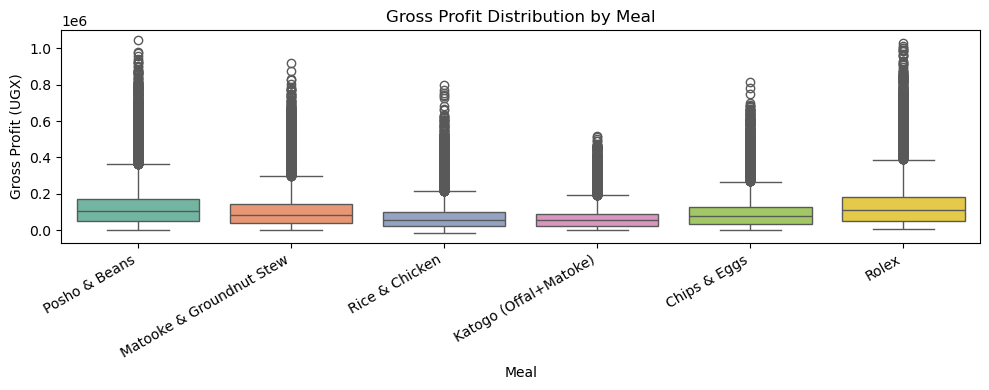

Meal
Rolex                       142340.0
Posho & Beans               136302.0
Matooke & Groundnut Stew    112265.0
Chips & Eggs                100520.0
Rice & Chicken               79619.0
Katogo (Offal+Matoke)        71431.0
Name: Gross_Profit_UGX, dtype: float64


In [3]:
# quick look at profit distribution across meals
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='Meal', y='Gross_Profit_UGX', palette='Set2')
plt.title('Gross Profit Distribution by Meal')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Gross Profit (UGX)')
plt.tight_layout()
plt.show()

print(df.groupby('Meal')['Gross_Profit_UGX'].mean().sort_values(ascending=False).round(0))

## Step 4 — Prepare Features

In [86]:
# profit margin: what share of revenue becomes profit
df['Profit_Margin'] = df['Gross_Profit_UGX'] / df['Revenue_UGX']

# cost ratio: ingredient cost as share of revenue
df['Cost_Ratio'] = df['Ingredient_Cost_UGX'] / df['Revenue_UGX']
df['Waste_Ratio']    = df['Waste_Cost_UGX'] / df['Revenue_UGX']
df['Sell_Through'] = df['Portions_Sold'] / df['Portions_Prepared']

# use three direct financial columns + two derived ratios
features = ['Profit_Margin', 'Cost_Ratio', 'Waste_Ratio', 'Sell_Through']

X = df[features].fillna(0).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature matrix shape:', X_scaled.shape)

Feature matrix shape: (58800, 4)


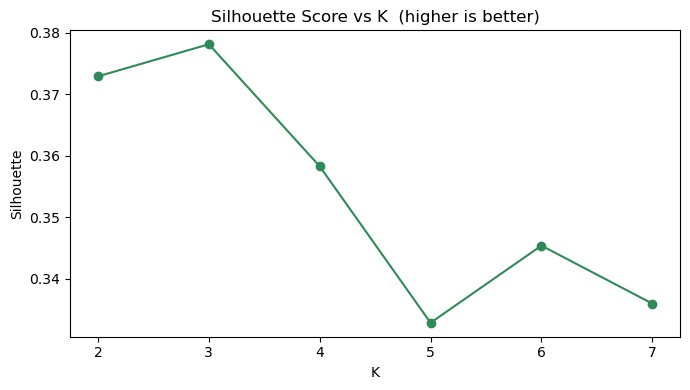

Best K by Silhouette: 3


In [87]:
sil_scores = []
K_range = range(2, 8)

for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=5000, random_state=42))

plt.figure(figsize=(7, 4))
plt.plot(K_range, sil_scores, 'o-', color='seagreen')
plt.title('Silhouette Score vs K  (higher is better)')
plt.xlabel('K')
plt.ylabel('Silhouette')
plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print('Best K by Silhouette:', best_k)

## Step 6 — Train the GMM

In [77]:
K = 3  # 3 clusters maps cleanly to Loss-Making / Break-Even / Profitable

gmm = GaussianMixture(n_components=K, covariance_type='full', n_init=5, random_state=42)
gmm.fit(X_scaled)

df['Cluster'] = gmm.predict(X_scaled)
df['Confidence'] = gmm.predict_proba(X_scaled).max(axis=1)

print('Cluster counts:')
print(df['Cluster'].value_counts().sort_index())
print('\nAverage confidence:', round(df['Confidence'].mean(), 4))

Cluster counts:
Cluster
0     9801
1    27276
2    21723
Name: count, dtype: int64

Average confidence: 0.8537


## Step 7 — Label the Clusters

In [93]:
# profile clusters by average gross profit
profile = df.groupby('Cluster')[[ 'Profit_Margin', 'Cost_Ratio', 'Waste_Ratio', 'Sell_Through']].mean().round(2)
print(profile)

# rank clusters from lowest to highest profit and assign labels
sorted_clusters = profile['Profit_Margin'].sort_values().index.tolist()

all_labels = ['LOW PROFIT', 'HIGH_PROFIT', 'PEAK_PROFIT']
labels = all_labels[:len(sorted_clusters)]

label_map = {cluster: labels[i] for i, cluster in enumerate(sorted_clusters)}
df['Profit_Regime'] = df['Cluster'].map(label_map)

print('\nCluster → Profit Regime:')
print(df.groupby(['Cluster', 'Profit_Regime'])['Gross_Profit_UGX'].mean().round(0))

         Profit_Margin  Cost_Ratio  Waste_Ratio  Sell_Through
Cluster                                                      
0                 0.21        0.68         0.11          0.87
1                 0.48        0.47         0.05          0.91
2                 0.37        0.52         0.11          0.82

Cluster → Profit Regime:
Cluster  Profit_Regime
0        LOW PROFIT        79611.0
1        PEAK_PROFIT      132704.0
2        HIGH_PROFIT       87299.0
Name: Gross_Profit_UGX, dtype: float64


## Step 8 — Evaluate the Model

Silhouette Score : 0.3673
Log-Likelihood   : 5.086
Avg Confidence   : 0.8537


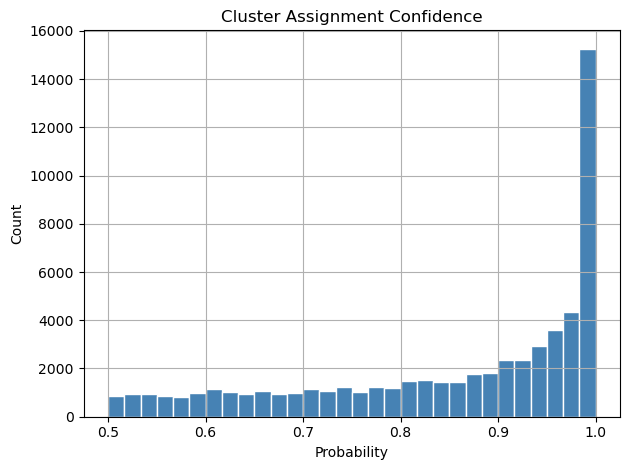

In [97]:
# silhouette score
sil = silhouette_score(X_scaled, df['Cluster'])
print('Silhouette Score :', round(sil, 4))

# log-likelihood
ll = gmm.score(X_scaled)
print('Log-Likelihood   :', round(ll, 4))

# confidence distribution
print('Avg Confidence   :', round(df['Confidence'].mean(), 4))

df['Confidence'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Cluster Assignment Confidence')
plt.xlabel('Probability')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

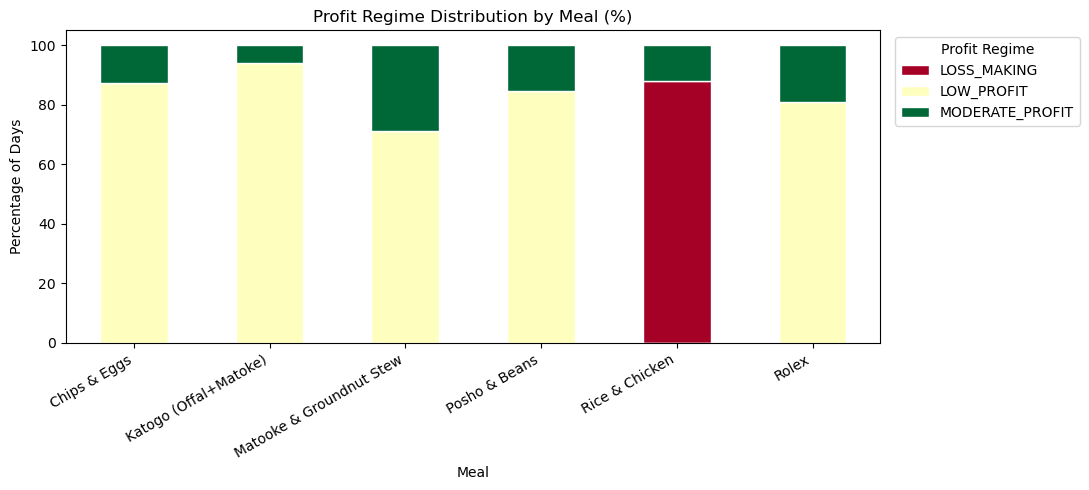

In [ ]:
# which meals fall into which profit regime most often?
meal_regime = df.groupby(['Meal', 'Profit_Regime']).size().unstack(fill_value=0)
meal_regime_pct = meal_regime.div(meal_regime.sum(axis=1), axis=0) * 100

meal_regime_pct.plot(kind='bar', stacked=True, figsize=(11, 5), colormap='RdYlGn', edgecolor='white')
plt.title('Profit Regime Distribution by Meal (%)')
plt.ylabel('Percentage of Days')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Profit Regime', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\arian\AppData\Local\Temp\ipykernel_67324\1193102051.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Profit_Regime', y='Gross_Profit_UGX', palette='RdYlGn')


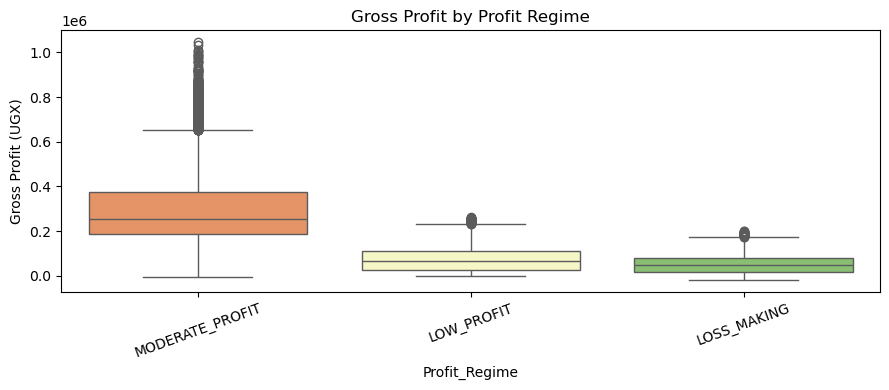

In [10]:
# profit distribution per regime
plt.figure(figsize=(9, 4))
sns.boxplot(data=df, x='Profit_Regime', y='Gross_Profit_UGX', palette='RdYlGn')
plt.title('Gross Profit by Profit Regime')
plt.ylabel('Gross Profit (UGX)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

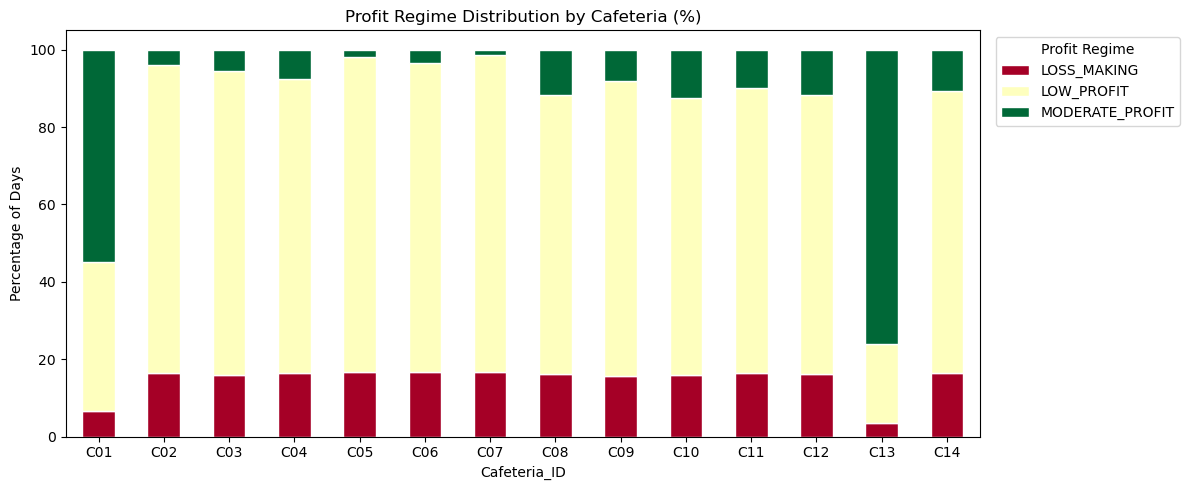

In [11]:
# which cafeterias are most often in the low profit regime?
caf_regime = df.groupby(['Cafeteria_ID', 'Profit_Regime']).size().unstack(fill_value=0)
caf_regime_pct = caf_regime.div(caf_regime.sum(axis=1), axis=0) * 100

caf_regime_pct.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='RdYlGn', edgecolor='white')
plt.title('Profit Regime Distribution by Cafeteria (%)')
plt.ylabel('Percentage of Days')
plt.xticks(rotation=0)
plt.legend(title='Profit Regime', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [104]:
def predict_profit_regime(gross_profit, revenue, waste_cost, ingredient_cost, sell_through):
    
    # calculate the two derived features
    profit_margin = gross_profit / revenue
    cost_ratio    = ingredient_cost / revenue
    waste_ratio   = waste_cost / revenue
    
    

    
    # put into a dataframe matching training feature order
    new_entry = pd.DataFrame({
        'Profit_Margin':    [profit_margin],
        'Cost_Ratio':       [cost_ratio],
        'Waste_Ratio':      [waste_ratio],
        'Sell_Through':     [sell_through]
    })
    
    # scale using the same scaler from training
    X_new = scaler.transform(new_entry.values)
    
    # predict
    cluster    = int(gmm.predict(X_new)[0])
    confidence = gmm.predict_proba(X_new).max(axis=1)[0]
    regime     = label_map[cluster]
    
    print('=== Profit Regime Prediction ===')
    print(f'Profit Margin  : {round(profit_margin * 100, 1)}%')
    print(f'Cost Ratio     : {round(cost_ratio * 100, 1)}%')
    print(f'Waste Ratio    : {round(waste_ratio * 100, 1)}%')
    print(f'Sell Through   : {round(sell_through * 100, 1)}%')
    print(f'Predicted Regime : {regime}')
    print(f'Confidence       : {round(confidence * 100, 1)}%')

In [63]:
print(df.groupby('Profit_Regime')[['Gross_Profit_UGX', 'Revenue_UGX', 'Waste_Cost_UGX', 'Profit_Margin']].mean().round(2))

               Gross_Profit_UGX  Revenue_UGX  Waste_Cost_UGX  Profit_Margin
Profit_Regime                                                              
HIGH_PROFIT           303648.10    759031.76        60943.79           0.41
LOSS_MAKING            54993.84    258709.32        27198.28           0.21
LOW_PROFIT             73859.23    169848.96        12627.07           0.43


In [85]:
print(df['Profit_Regime'].value_counts())

Profit_Regime
HIGH_PROFIT    27276
LOW_PROFIT     21723
LOSS_MAKING     9801
Name: count, dtype: int64


In [105]:
predict_profit_regime(
    gross_profit    = 50000,
    revenue         = 100000,
    waste_cost      = 15000,
    ingredient_cost = 10000,
    sell_through=0.75
)

=== Profit Regime Prediction ===
Profit Margin  : 50.0%
Cost Ratio     : 10.0%
Waste Ratio    : 15.0%
Sell Through   : 75.0%
Predicted Regime : HIGH_PROFIT
Confidence       : 100.0%
